<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Breakout/Large_Earnings_Moves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Post-Earnings Volatility Breakout Strategy

This notebook implements a technical analysis scanner designed to identify **Post-Earnings Volatility Breakouts**. The strategy focuses on identifying stocks that experience significant price movements (up or down) on or immediately after their earnings report, relative to their historical volatility.

**Key Features:**
*   **Dynamic Signal Detection:** Identifies trigger days where the absolute daily return on or after an earnings announcement exceeds a multiple of the historical rolling volatility (configurable via `EARNINGS_VOL_MULTIPLIER`).
*   **Ticker Loading:** Loads ticker symbols from a Google Drive file or falls back to a predefined list.
*   **Historical Data Fetching:** Downloads historical stock data using `yfinance`.
*   **RSI Calculation:** Computes the 14-period Relative Strength Index (RSI) for each ticker on the day prior to the earnings event.
*   **Forward Performance Tracking:** Automatically calculates forward returns (5-day, 10-day, and 20-day) following each earnings breakout trigger.

In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta

In [13]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: df_symbols
Deleted DataFrame: raw_data
Deleted DataFrame: df_ticker
Deleted DataFrame: df_earnings
Deleted DataFrame: df_earnings_results
Deleted DataFrame: earnings_summary
Deleted DataFrame: nvda_earnings_data
Deleted DataFrame: df_up
Deleted DataFrame: df_down
Deleted DataFrame: summary_df
All DataFrames cleared from memory.


In [14]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

In [15]:
# ========================================================
# LOAD TICKERS & FILTER OUT ETFs (No Earnings Reports)
# ========================================================

# Default fallback list of verified equities if Drive file is missing/broken
fallback_tickers = ["AAPL", "MSFT", "NVDA", "AMD", "TSLA"]

try:
    print("Attempting to pull tickers from the OptionVolume file...")
    df_symbols = pd.read_csv(OptionVolume)

    if 'Symbol' in df_symbols.columns:
        # Pull raw symbols, convert to string, clean whitespace, and get unique values
        raw_tickers = df_symbols['Symbol'].dropna().astype(str).unique().tolist()
        raw_tickers = [t.strip().upper() for t in raw_tickers if t.strip()]

        print(f"Successfully loaded {len(raw_tickers)} raw tickers from file.")
        print("Filtering out ETFs and non-equity assets (this may take a few seconds)...")

        cleaned_tickers = []
        for ticker in raw_tickers:
            try:
                # Initialize ticker object to inspect metadata
                tk = yf.Ticker(ticker)
                quote_type = tk.info.get('quoteType', '').upper()

                # Filter out ETFs, Mutual Funds, and General Indices
                if quote_type == 'ETF':
                    print(f"  -> Skipping {ticker}: Identified as an ETF.")
                elif quote_type in ['MUTUALFUND', 'INDEX']:
                    print(f"  -> Skipping {ticker}: Identified as {quote_type}.")
                else:
                    # Keep 'EQUITY' or entries where Yahoo doesn't explicitly flag an alternative
                    cleaned_tickers.append(ticker)

            except Exception:
                # If the metadata check fails due to network/API quirks,
                # we keep the ticker anyway so we don't accidentally drop a valid stock.
                cleaned_tickers.append(ticker)

        tickers = cleaned_tickers
        print(f"\nFiltering complete. Extracted {len(tickers)} individual corporate equities.")

    else:
        raise KeyError("'Symbol' column was not found in the downloaded file.")

except Exception as e:
    print(f"\nFailed to load/filter tickers from Google Drive ({e}).")
    print("Falling back to the hardcoded equity ticker list.")
    tickers = fallback_tickers

print(f"Final ticker list size for earnings analysis: {len(tickers)}")
display(tickers)

Attempting to pull tickers from the OptionVolume file...
Successfully loaded 100 raw tickers from file.
Filtering out ETFs and non-equity assets (this may take a few seconds)...
  -> Skipping SPY: Identified as an ETF.
  -> Skipping QQQ: Identified as an ETF.
  -> Skipping SLV: Identified as an ETF.
  -> Skipping GLD: Identified as an ETF.
  -> Skipping IBIT: Identified as an ETF.
  -> Skipping USO: Identified as an ETF.
  -> Skipping SMH: Identified as an ETF.
  -> Skipping SOXL: Identified as an ETF.
  -> Skipping TQQQ: Identified as an ETF.
  -> Skipping TLT: Identified as an ETF.
  -> Skipping GDX: Identified as an ETF.
  -> Skipping XLE: Identified as an ETF.
  -> Skipping IGV: Identified as an ETF.
  -> Skipping DIA: Identified as an ETF.

Filtering complete. Extracted 86 individual corporate equities.
Final ticker list size for earnings analysis: 86


['TSLA',
 'NVDA',
 'MSFT',
 'MU',
 'META',
 'AMZN',
 'MSTR',
 'AAPL',
 'SNDK',
 'PLTR',
 'AMD',
 'IWM',
 'ORCL',
 'GOOGL',
 'NFLX',
 'INTC',
 'COIN',
 'AVGO',
 'GOOG',
 'HOOD',
 'CRWV',
 'TSM',
 'NOW',
 'UNH',
 'BABA',
 'LLY',
 'ASTS',
 'CVNA',
 'NBIS',
 'BE',
 'IREN',
 'ADBE',
 'CRCL',
 'COST',
 'WDC',
 'XOM',
 'APP',
 'LITE',
 'RKLB',
 'RDDT',
 'QCOM',
 'CAR',
 'GS',
 'CRM',
 'JPM',
 'MRVL',
 'ARM',
 'STX',
 'CAT',
 'CVX',
 'BA',
 'WMT',
 'CRWD',
 'SMCI',
 'NKE',
 'OKLO',
 'SNOW',
 'NVO',
 'ZS',
 'IBM',
 'AAOI',
 'AMAT',
 'LULU',
 'BRK-B',
 'HIMS',
 'PANW',
 'LRCX',
 'RBLX',
 'C',
 'FSLR',
 'GME',
 'VRT',
 'SHOP',
 'MDB',
 'GEV',
 'GLW',
 'CSCO',
 'V',
 'TGT',
 'APLD',
 'ASML',
 'MRK',
 'PYPL',
 'FCX',
 'INTU',
 'IONQ']

In [16]:
# ---- EARNINGS PARAMETERS ----
# Choose your target volatility multiplier to test for earnings reactions
EARNINGS_VOL_MULTIPLIER = 3.0

START_DATE = "2024-01-01"
END_DATE = "2026-12-31"
VOL_WINDOW = 60          # Rolling window for volatility

# Calculate a warm-up start date (~90 calendar days to safely get 60 trading days)
start_dt = datetime.strptime(START_DATE, "%Y-%m-%d")
warmup_start_dt = start_dt - timedelta(days=90)
WARMUP_START_DATE = warmup_start_dt.strftime("%Y-%m-%d")

print(f"Parameters loaded. Scanner configured for a {EARNINGS_VOL_MULTIPLIER}x volatility move on or after earnings.")

Parameters loaded. Scanner configured for a 3.0x volatility move on or after earnings.


In [17]:
# ==========================================
# FETCH HISTORICAL DAILY PRICE DATA
# ==========================================

print(f"Fetching historical data from {WARMUP_START_DATE} to {END_DATE}...")

try:
    # Fetch data in bulk to minimize API calls
    raw_data = yf.download(tickers, start=WARMUP_START_DATE, end=END_DATE, group_by='ticker')
    print("\nHistorical data successfully downloaded!")
except Exception as e:
    print(f"Error fetching historical data: {e}")

/tmp/ipykernel_1468/516938562.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start=WARMUP_START_DATE, end=END_DATE, group_by='ticker')
[                       0%                       ]

Fetching historical data from 2023-10-03 to 2026-12-31...


[*********************100%***********************]  86 of 86 completed


Historical data successfully downloaded!


In [18]:
# Helper function for RSI
def calculate_rsi(df, window=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Use ewm for exponential weighted moving average
    avg_gain = gain.ewm(com=window - 1, adjust=False).mean()
    avg_loss = loss.ewm(com=window - 1, adjust=False).mean()

    # Avoid division by zero for rs where avg_loss is 0
    rs = np.where(avg_loss == 0, np.inf, avg_gain / avg_loss)
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Master list to store post-earnings trigger events
earnings_trigger_records = []

print(f"Starting post-earnings analysis for {len(tickers)} tickers...")

for ticker in tickers:
    if ticker not in raw_data.columns.levels[0]:
        continue

    # Extract ticker data and clean missing rows
    df_ticker = raw_data[ticker].dropna(subset=['Close']).copy()
    if len(df_ticker) < VOL_WINDOW:
        continue

    # Calculate returns and rolling historical volatility baseline
    df_ticker['Daily_Return'] = df_ticker['Close'].pct_change()
    df_ticker['Return_Mag'] = df_ticker['Daily_Return'].abs()
    df_ticker['Hist_Vol'] = df_ticker['Daily_Return'].rolling(window=VOL_WINDOW).std()
    df_ticker['Vol_Threshold'] = df_ticker['Hist_Vol'] * EARNINGS_VOL_MULTIPLIER

    # Calculate RSI for the ticker (before date filtering to ensure full history for EWM)
    df_ticker['RSI_14'] = calculate_rsi(df_ticker, window=14)

    # Fetch historical earnings dates from Yahoo Finance
    try:
        ticker_obj = yf.Ticker(ticker)
        df_earnings = ticker_obj.get_earnings_dates(limit=50)

        if df_earnings is None or df_earnings.empty:
            continue

        # Standardize dates to match the historical price index (tz-naive, midnight normalized)
        earnings_dates = pd.to_datetime(df_earnings.index).tz_localize(None).normalize().unique()
    except Exception as e:
        # Gracefully skip if a ticker fails to fetch to prevent notebook crash
        print(f"Skipping {ticker}: Earnings data unavailable ({e})")
        continue

    # Evaluate price moves around each earnings date
    for edate in earnings_dates:
        # Restrict dates to your specified global date windows
        if edate < pd.to_datetime(START_DATE) or edate > pd.to_datetime(END_DATE):
            continue

        # Find valid trading days on or immediately following the earnings event
        trading_days_after = df_ticker.index[df_ticker.index >= edate]
        if len(trading_days_after) < 2:
            continue

        day_of = trading_days_after[0] # First trading day on or after earnings announcement

        # --- Calculate RSI on the last trading day BEFORE earnings ---
        idx_loc_day_of = df_ticker.index.get_loc(day_of)
        if idx_loc_day_of == 0: # Cannot get a day before if it's the first trading day
            continue
        day_before_earnings = df_ticker.index[idx_loc_day_of - 1]
        rsi_value_before_earnings = df_ticker.loc[day_before_earnings, 'RSI_14']
        # -----------------------------------------------------------

        day_after = trading_days_after[1]

        row_day_of = df_ticker.loc[day_of]
        row_day_after = df_ticker.loc[day_after]

        # Determine if either day broke past the volatility threshold
        is_day_of_valid = row_day_of['Return_Mag'] > row_day_of['Vol_Threshold'] if not pd.isna(row_day_of['Vol_Threshold']) else False
        is_day_after_valid = row_day_after['Return_Mag'] > row_day_after['Vol_Threshold'] if not pd.isna(row_day_after['Vol_Threshold']) else False

        trigger_day = None
        # If both days qualified, look at the day with the larger impulse response
        if is_day_of_valid and is_day_after_valid:
            trigger_day = day_of if row_day_of['Return_Mag'] >= row_day_after['Return_Mag'] else day_after
        elif is_day_of_valid:
            trigger_day = day_of
        elif is_day_after_valid:
            trigger_day = day_after

        if trigger_day is not None:
            idx_loc = df_ticker.index.get_loc(trigger_day)

            # Confirm we have at least 20 trading days of future data to calculate the holding period
            if idx_loc + 20 < len(df_ticker):
                close_base = df_ticker.iloc[idx_loc]['Close']

                ret_5d  = df_ticker.iloc[idx_loc + 5]['Close'] / close_base - 1
                ret_10d = df_ticker.iloc[idx_loc + 10]['Close'] / close_base - 1
                ret_20d = df_ticker.iloc[idx_loc + 20]['Close'] / close_base - 1

                direction = 'up' if df_ticker.iloc[idx_loc]['Daily_Return'] > 0 else 'down'

                earnings_trigger_records.append({
                    'Ticker': ticker,
                    'Earnings_Date': edate.strftime('%Y-%m-%d'),
                    'Trigger_Date': trigger_day.strftime('%Y-%m-%d'),
                    'Direction': direction,
                    'Earnings_Move': df_ticker.iloc[idx_loc]['Daily_Return'],
                    'Fwd_Ret_5d': ret_5d,
                    'Fwd_Ret_10d': ret_10d,
                    'Fwd_Ret_20d': ret_20d,
                    'RSI_14_Before_Earnings': rsi_value_before_earnings
                })

# Convert results to a unified DataFrame
if earnings_trigger_records:
    df_earnings_results = pd.DataFrame(earnings_trigger_records)
    print(f"\nProcessing complete! Found {len(df_earnings_results)} post-earnings breakdown/breakout triggers.")
else:
    df_earnings_results = pd.DataFrame()
    print("\nNo earnings dates matched the volatility multiplier constraints within this historical range.")

Starting post-earnings analysis for 86 tickers...


ERROR:yfinance:IWM: No earnings dates found, symbol may be delisted



Processing complete! Found 308 post-earnings breakdown/breakout triggers.


In [19]:
if not df_earnings_results.empty:
    print(f"=== POST-EARNINGS PERFORMANCE SUMMARY ({EARNINGS_VOL_MULTIPLIER}x MULTIPLIER) ===")

    # Aggregate data by direction of the reaction
    earnings_summary = df_earnings_results.groupby('Direction').agg(
        Event_Count=('Earnings_Move', 'count'),
        Avg_Initial_Move=('Earnings_Move', 'mean'),
        Avg_Fwd_5d=('Fwd_Ret_5d', 'mean'),
        Median_Fwd_5d=('Fwd_Ret_5d', 'median'),
        Win_Rate_5d=('Fwd_Ret_5d', lambda x: (x > 0).mean()),
        Avg_Fwd_10d=('Fwd_Ret_10d', 'mean'),
        Median_Fwd_10d=('Fwd_Ret_10d', 'median'),
        Win_Rate_10d=('Fwd_Ret_10d', lambda x: (x > 0).mean()),
        Avg_Fwd_20d=('Fwd_Ret_20d', 'mean'),
        Median_Fwd_20d=('Fwd_Ret_20d', 'median'),
        Win_Rate_20d=('Fwd_Ret_20d', lambda x: (x > 0).mean())
    )

    # Apply percentage formatting for easy scanning
    pct_formatters = {c: '{:,.2%}'.format for c in earnings_summary.columns if 'Avg' in c or 'Median' in c or 'Win_Rate' in c}
    print(earnings_summary.to_string(formatters=pct_formatters))

    # Display the full raw trigger data for deep inspection
    print("\n=== FULL DRILLDOWN (ALL EVENTS) ===")
    # Reorder columns to place RSI_14_Before_Earnings after Trigger_Date
    display_columns = [
        'Ticker', 'Earnings_Date', 'Trigger_Date', 'RSI_14_Before_Earnings',
        'Direction', 'Earnings_Move', 'Fwd_Ret_5d', 'Fwd_Ret_10d', 'Fwd_Ret_20d'
    ]
    display(df_earnings_results[display_columns])
else:
    print("No data available to display summary statistics.")

=== POST-EARNINGS PERFORMANCE SUMMARY (3.0x MULTIPLIER) ===
           Event_Count Avg_Initial_Move Avg_Fwd_5d Median_Fwd_5d Win_Rate_5d Avg_Fwd_10d Median_Fwd_10d Win_Rate_10d Avg_Fwd_20d Median_Fwd_20d Win_Rate_20d
Direction                                                                                                                                                   
down               153          -12.74%     -0.63%        -1.39%      39.22%      -0.14%         -1.07%       43.79%       0.23%         -0.74%       47.06%
up                 155           16.53%      2.11%         1.06%      55.48%       5.30%          3.00%       61.29%       7.67%          4.38%       65.81%

=== FULL DRILLDOWN (ALL EVENTS) ===


,Ticker,Earnings_Date,Trigger_Date,RSI_14_Before_Earnings,Direction,Earnings_Move,Fwd_Ret_5d,Fwd_Ret_10d,Fwd_Ret_20d
0,TSLA,2024-10-23,2024-10-24,39.182775,up,0.219190,-0.040809,0.139857,0.303900
1,TSLA,2024-07-23,2024-07-24,63.959881,down,-0.123346,0.074448,-0.112181,0.033705
2,TSLA,2024-04-23,2024-04-24,27.834502,up,0.120611,0.110159,0.077654,0.110899
3,TSLA,2024-01-24,2024-01-25,27.773128,down,-0.121253,0.034113,0.037946,0.051142
4,NVDA,2024-02-21,2024-02-22,63.340576,up,0.164009,0.007309,0.179981,0.164268
...,...,...,...,...,...,...,...,...,...
303,INTU,2024-11-21,2024-11-22,49.870247,down,-0.056844,-0.009451,0.010092,-0.002843
304,INTU,2024-08-22,2024-08-23,63.316341,down,-0.068301,0.016794,0.011519,0.035686
305,INTU,2024-05-23,2024-05-24,65.673660,down,-0.083457,-0.065520,-0.065487,0.038683
306,IONQ,2026-02-25,2026-02-26,35.890854,up,0.217029,-0.118885,-0.192025,-0.270059


In [20]:
def get_earnings_results_for_ticker(ticker_symbol):
    """
    Filters the df_earnings_results DataFrame for a specific ticker symbol.

    Args:
        ticker_symbol (str): The stock ticker symbol to filter by.

    Returns:
        pandas.DataFrame: A DataFrame containing earnings results for the specified ticker.
                          Returns an empty DataFrame if no results are found.
    """
    if 'df_earnings_results' in globals() and not df_earnings_results.empty:
        return df_earnings_results[df_earnings_results['Ticker'] == ticker_symbol].copy()
    else:
        print("df_earnings_results DataFrame is not available or is empty.")
        return pd.DataFrame()

# Demo: Get earnings results for a specific ticker (e.g., 'NVDA')
example_ticker = 'AVGO'
nvda_earnings_data = get_earnings_results_for_ticker(example_ticker)

if not nvda_earnings_data.empty:
    print(f"\nEarnings results for {example_ticker}:")
    display(nvda_earnings_data)
else:
    print(f"No earnings results found for {example_ticker}.")


Earnings results for AVGO:


,Ticker,Earnings_Date,Trigger_Date,Direction,Earnings_Move,Fwd_Ret_5d,Fwd_Ret_10d,Fwd_Ret_20d,RSI_14_Before_Earnings
61,AVGO,2026-06-03,2026-06-04,down,-0.125869,-0.079588,-0.018047,-0.106033,74.752379
62,AVGO,2025-12-11,2025-12-12,down,-0.114280,-0.054372,-0.027426,-0.012896,68.089311
63,AVGO,2025-09-04,2025-09-05,up,0.094054,0.074591,0.030010,0.012123,55.301482
64,AVGO,2024-12-12,2024-12-13,up,0.244326,-0.017838,0.050762,0.016952,62.566670
65,AVGO,2024-06-12,2024-06-13,up,0.122687,-0.012127,-0.040716,0.024213,64.285171


In [21]:
# ========================================================
# DIRECTIONAL BREAKDOWN & AVERAGE RETURNS
# ========================================================

if 'df_earnings_results' in globals() and not df_earnings_results.empty:
    # Break the results into two separate DataFrames based on direction
    df_up = df_earnings_results[df_earnings_results['Direction'] == 'up'].copy()
    df_down = df_earnings_results[df_earnings_results['Direction'] == 'down'].copy()

    # Define the target return columns
    ret_cols = ['Fwd_Ret_5d', 'Fwd_Ret_10d', 'Fwd_Ret_20d']

    print(f"=== UPWARD EARNINGS BREAKOUTS ({len(df_up)} events) ===")
    if not df_up.empty:
        up_avgs = df_up[ret_cols].mean()
        print(f"Average 5-Day Return:  {up_avgs['Fwd_Ret_5d']:.2%}")
        print(f"Average 10-Day Return: {up_avgs['Fwd_Ret_10d']:.2%}")
        print(f"Average 20-Day Return: {up_avgs['Fwd_Ret_20d']:.2%}")
    else:
        print("No upward breakouts found.")

    print(f"\n=== DOWNWARD EARNINGS BREAKDOWNS ({len(df_down)} events) ===")
    if not df_down.empty:
        down_avgs = df_down[ret_cols].mean()
        print(f"Average 5-Day Return:  {down_avgs['Fwd_Ret_5d']:.2%}")
        print(f"Average 10-Day Return: {down_avgs['Fwd_Ret_10d']:.2%}")
        print(f"Average 20-Day Return: {down_avgs['Fwd_Ret_20d']:.2%}")
    else:
        print("No downward breakdowns found.")

    # Optional: Display a side-by-side DataFrame for clean viewing
    print("\n=== SUMMARY TABLE ===")
    summary_df = pd.DataFrame({
        'Upward Moves': df_up[ret_cols].mean(),
        'Downward Moves': df_down[ret_cols].mean()
    }).T

    # Format as percentages
    display(summary_df.style.format("{:.2%}"))

else:
    print("No earnings results found. Please ensure the earnings processing cell ran successfully.")

=== UPWARD EARNINGS BREAKOUTS (155 events) ===
Average 5-Day Return:  2.11%
Average 10-Day Return: 5.30%
Average 20-Day Return: 7.67%

=== DOWNWARD EARNINGS BREAKDOWNS (153 events) ===
Average 5-Day Return:  -0.63%
Average 10-Day Return: -0.14%
Average 20-Day Return: 0.23%

=== SUMMARY TABLE ===


,Fwd_Ret_5d,Fwd_Ret_10d,Fwd_Ret_20d
Upward Moves,2.11%,5.30%,7.67%
Downward Moves,-0.63%,-0.14%,0.23%


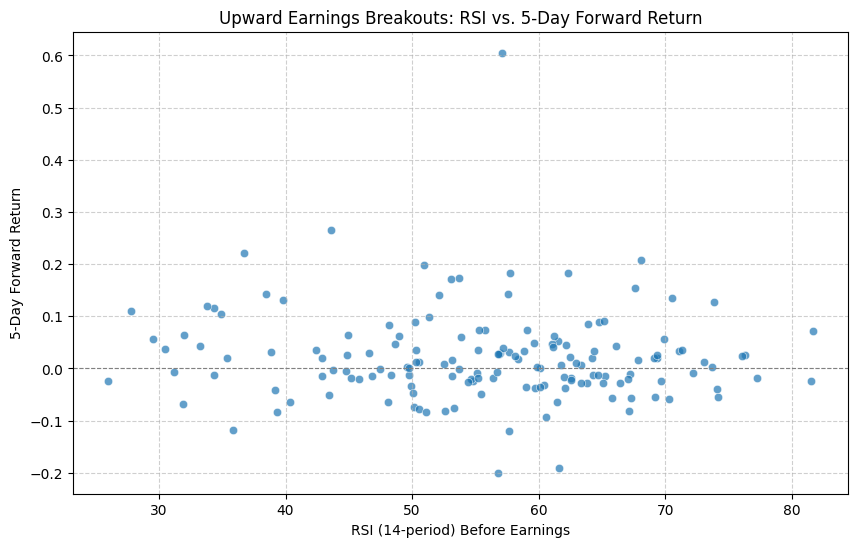

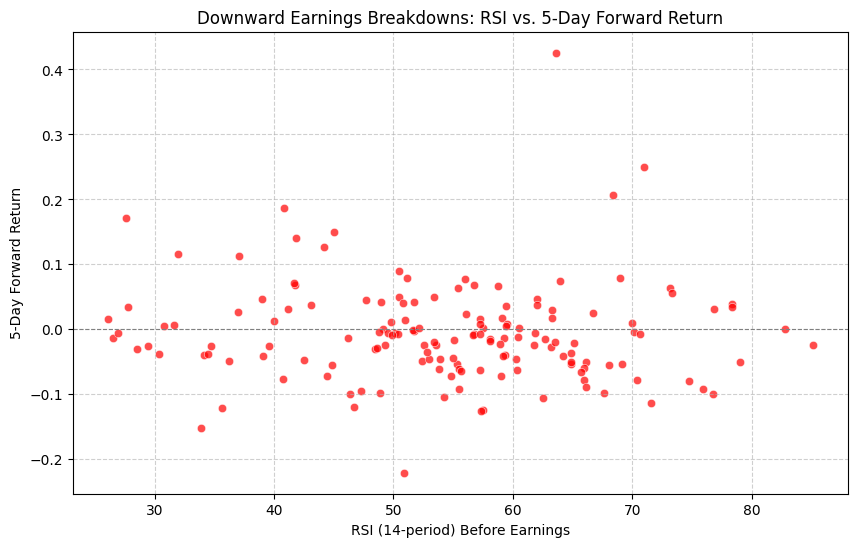

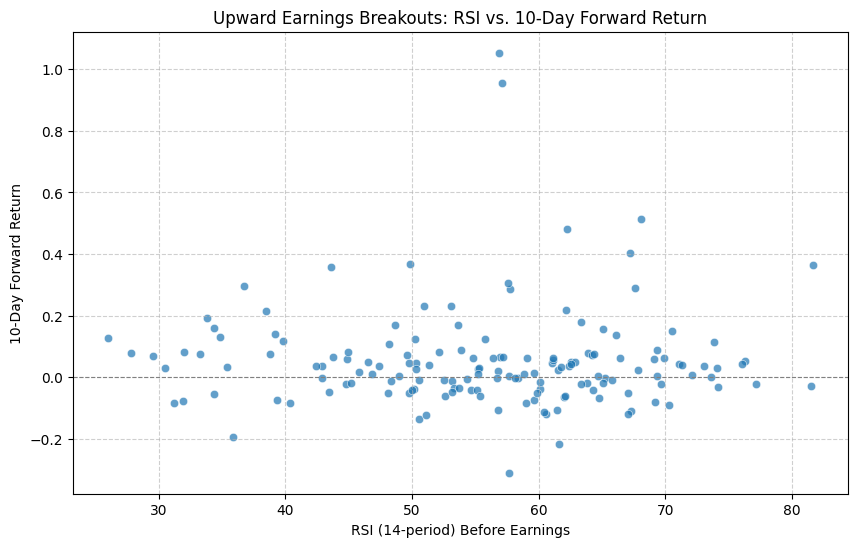

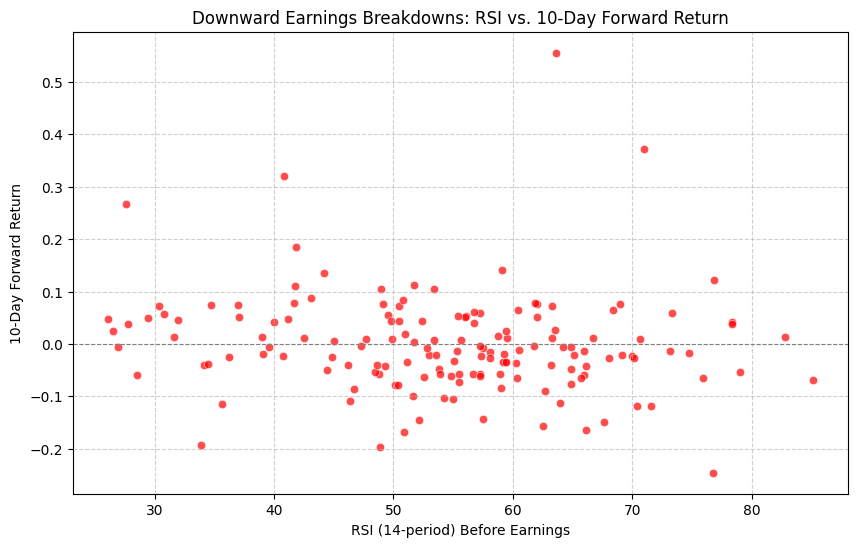

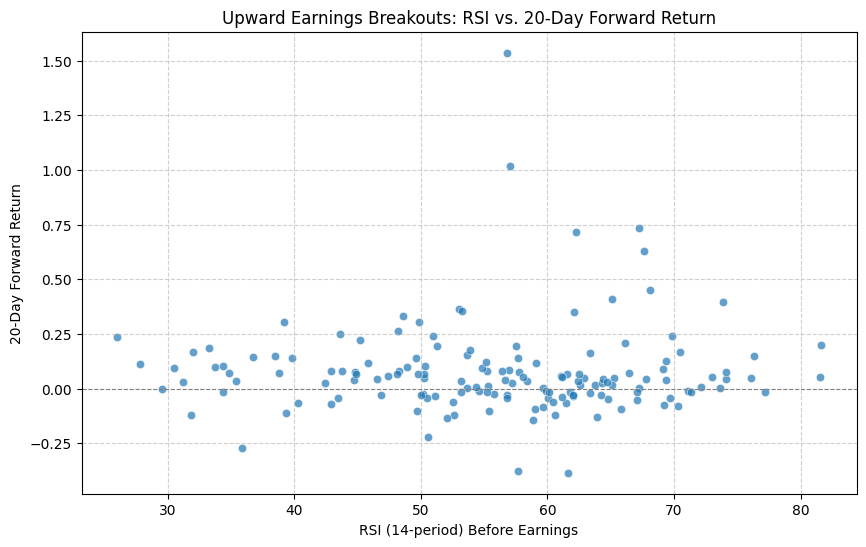

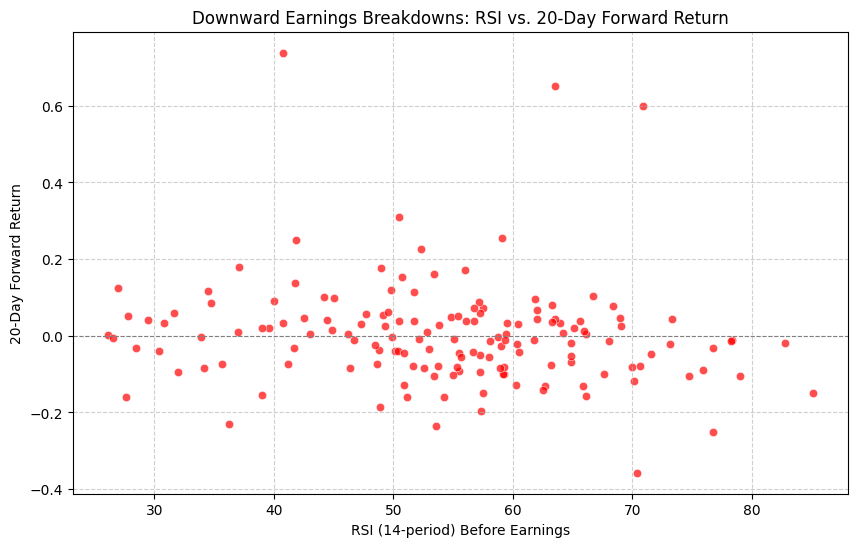

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create df_up and df_down to ensure they have the latest columns, including RSI_14_Before_Earnings.
# This addresses cases where df_up/df_down might be outdated relative to df_earnings_results.
if 'df_earnings_results' in globals() and not df_earnings_results.empty:
    df_up = df_earnings_results[df_earnings_results['Direction'] == 'up'].copy()
    df_down = df_earnings_results[df_earnings_results['Direction'] == 'down'].copy()
else:
    print("df_earnings_results DataFrame is not available or is empty. Cannot generate plots.")
    # Exit or handle the error gracefully if df_earnings_results is missing


# Scatter plot for Upward Earnings Breakouts (5-Day Forward Return)
if not df_up.empty:
    fig_up_5d = plt.figure(figsize=(10, 6))
    sns.scatterplot(x='RSI_14_Before_Earnings', y='Fwd_Ret_5d', data=df_up, alpha=0.7)
    plt.title('Upward Earnings Breakouts: RSI vs. 5-Day Forward Return')
    plt.xlabel('RSI (14-period) Before Earnings')
    plt.ylabel('5-Day Forward Return')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Scatter plot for Downward Earnings Breakdowns (5-Day Forward Return)
if not df_down.empty:
    fig_down_5d = plt.figure(figsize=(10, 6))
    sns.scatterplot(x='RSI_14_Before_Earnings', y='Fwd_Ret_5d', data=df_down, alpha=0.7, color='red')
    plt.title('Downward Earnings Breakdowns: RSI vs. 5-Day Forward Return')
    plt.xlabel('RSI (14-period) Before Earnings')
    plt.ylabel('5-Day Forward Return')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Scatter plot for Upward Earnings Breakouts (10-Day Forward Return)
if not df_up.empty:
    fig_up_10d = plt.figure(figsize=(10, 6))
    sns.scatterplot(x='RSI_14_Before_Earnings', y='Fwd_Ret_10d', data=df_up, alpha=0.7)
    plt.title('Upward Earnings Breakouts: RSI vs. 10-Day Forward Return')
    plt.xlabel('RSI (14-period) Before Earnings')
    plt.ylabel('10-Day Forward Return')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Scatter plot for Downward Earnings Breakdowns (10-Day Forward Return)
if not df_down.empty:
    fig_down_10d = plt.figure(figsize=(10, 6))
    sns.scatterplot(x='RSI_14_Before_Earnings', y='Fwd_Ret_10d', data=df_down, alpha=0.7, color='red')
    plt.title('Downward Earnings Breakdowns: RSI vs. 10-Day Forward Return')
    plt.xlabel('RSI (14-period) Before Earnings')
    plt.ylabel('10-Day Forward Return')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Scatter plot for Upward Earnings Breakouts (20-Day Forward Return)
if not df_up.empty:
    fig_up_20d = plt.figure(figsize=(10, 6))
    sns.scatterplot(x='RSI_14_Before_Earnings', y='Fwd_Ret_20d', data=df_up, alpha=0.7)
    plt.title('Upward Earnings Breakouts: RSI vs. 20-Day Forward Return')
    plt.xlabel('RSI (14-period) Before Earnings')
    plt.ylabel('20-Day Forward Return')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Scatter plot for Downward Earnings Breakdowns (20-Day Forward Return)
if not df_down.empty:
    fig_down_20d = plt.figure(figsize=(10, 6))
    sns.scatterplot(x='RSI_14_Before_Earnings', y='Fwd_Ret_20d', data=df_down, alpha=0.7, color='red')
    plt.title('Downward Earnings Breakdowns: RSI vs. 20-Day Forward Return')
    plt.xlabel('RSI (14-period) Before Earnings')
    plt.ylabel('20-Day Forward Return')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()